# Step 2: EDA & Data Cleaning

Explore missing patterns, default rates by segment, and clean data for modeling.

In [1]:
import sys
sys.path.insert(0, '/home/jovyan/work/src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from spark_utils import get_spark_session, load_parquet, save_parquet
from data_cleaning import encode_target, compute_missing_rate, create_lgd_column, create_ead_column, handle_missing_numeric, handle_missing_categorical

In [2]:
SAMPLE_MODE = False

## 2.1 Load Data

In [3]:
spark = get_spark_session()
df = spark.read.parquet('/home/jovyan/work/data/parquet/accepted_raw.parquet')

Spark driver memory: 7g


## 2.2 Missing Value Analysis

In [4]:
missing = compute_missing_rate(df)
missing_df = pd.DataFrame(missing.items(), columns=['column', 'missing_rate'])
missing_df[missing_df['missing_rate'] > 0].head(20)

,column,missing_rate
0,member_id,1.0000
1,orig_projected_additional_accrued_interest,0.9962
2,hardship_reason,0.9952
3,hardship_status,0.9952
4,deferral_term,0.9952
5,hardship_amount,0.9952
6,hardship_start_date,0.9952
7,hardship_end_date,0.9952
8,payment_plan_start_date,0.9952
9,hardship_length,0.9952


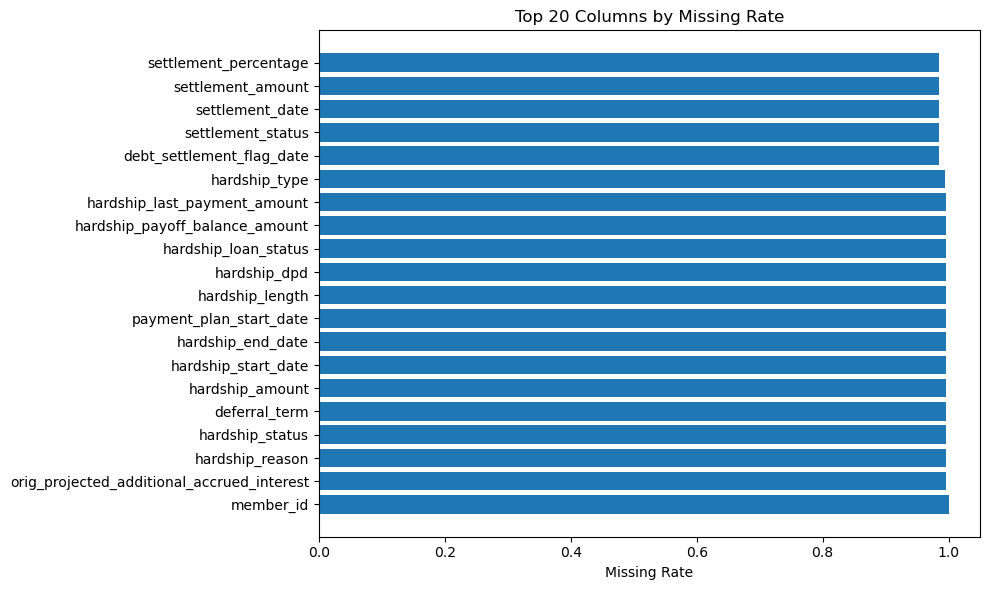

In [5]:
# Visualize top 20 missing columns
top_missing = missing_df[missing_df['missing_rate'] > 0].head(20)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_missing['column'], top_missing['missing_rate'])
ax.set_xlabel('Missing Rate')
ax.set_title('Top 20 Columns by Missing Rate')
plt.tight_layout()
plt.show()

## 2.3 Target Variable Encoding

In [6]:
df = encode_target(df)
df.groupBy('default_flag').count().show()

+------------+-------+
|default_flag|  count|
+------------+-------+
|           1| 290826|
|           0|1969875|
+------------+-------+



## 2.4 Default Rate by Segment

In [7]:
# Default rate by grade
from pyspark.sql import functions as F

grade_default = df.groupBy('grade').agg(
    F.mean('default_flag').alias('default_rate'),
    F.count('*').alias('count')
).orderBy('grade')
grade_default.show()

+-----+-------------------+------+
|grade|       default_rate| count|
+-----+-------------------+------+
| NULL|                0.0|    33|
|    A|0.03587767044549185|433027|
|    B| 0.0865758329729021|663557|
|    C|0.14361752041756595|650053|
|    D|0.20351453653243903|324424|
|    E|0.28284637899129306|135639|
|    F| 0.3642344497607656| 41800|
|    G| 0.4000657462195924| 12168|
+-----+-------------------+------+



In [8]:
# Default rate by application type
df.groupBy('application_type').agg(
    F.mean('default_flag').alias('default_rate'),
    F.count('*').alias('count')
).show()

+----------------+-------------------+-------+
|application_type|       default_rate|  count|
+----------------+-------------------+-------+
|       Joint App|0.07064866208267749| 120710|
|            NULL|0.17045454545454544|     88|
|      Individual|0.13191276168363633|2139702|
|        Oct-2016|                1.0|      1|
|             1.0|0.07017543859649122|     57|
|           699.0|                0.0|      2|
|        Dec-2017|                0.0|      1|
|           42.85|                0.0|      1|
|        Oct-2010|                1.0|      1|
|           675.0|                0.0|      2|
|        Jan-2012|                0.0|      1|
|        May-2010|                1.0|      1|
|           749.0|                0.0|      1|
|           709.0|                0.0|      2|
|        Jul-2010|                0.0|      1|
|        Jun-2011|                0.0|      1|
|           710.0|                0.0|      2|
|         11975.3|                1.0|      1|
|        Jul-

## 2.5 LGD Distribution

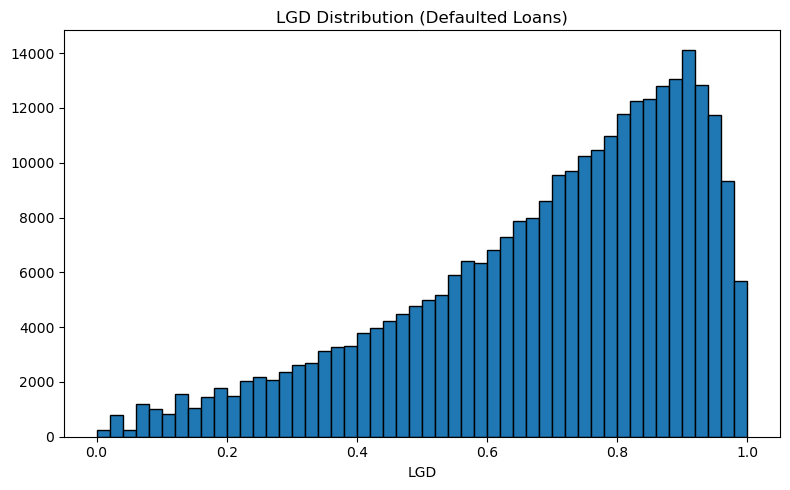

In [9]:
df = create_lgd_column(df)
df = create_ead_column(df)

# LGD histogram (zero-inflated / bimodal)
lgd_pd = df.filter(F.col('default_flag') == 1).select('lgd').toPandas()
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(lgd_pd['lgd'].dropna(), bins=50, edgecolor='black')
ax.set_xlabel('LGD')
ax.set_title('LGD Distribution (Defaulted Loans)')
plt.tight_layout()
plt.show()

## 2.6 Handle Missing Values & Save

In [10]:
# TODO: specify numeric and categorical columns for imputation
# numeric_cols = ['annual_inc', 'dti', 'revol_util', ...]
# categorical_cols = ['emp_title', 'title', ...]
# df = handle_missing_numeric(df, numeric_cols)
# df = handle_missing_categorical(df, categorical_cols)

save_parquet(df, '/home/jovyan/work/data/parquet/accepted_cleaned.parquet')
print('Cleaned data saved.')

Saved to /home/jovyan/work/data/parquet/accepted_cleaned.parquet
Cleaned data saved.
